# Car price — Linear Regression + assumption checks
All settings live in `config.py`. Pipeline: load → split (train/val/test) → group rare levels (fit on train) →
for each target transform (`none → log → Box-Cox → Yeo-Johnson`, plus the regression6 alternatives `quantile` and `quantile_z3`) fit OLS on **train**, run every assumption test on train residuals,
score on **validation** → pick best → evaluate **test** once.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan, lilliefors
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import config as C

pd.set_option("display.width", 200, "display.max_columns", 50)
rng = np.random.default_rng(C.SEED)

## 1. Load

In [2]:
df = pd.read_csv(C.DATA_PATH)
assert (df["year"] + df["car_age"]).nunique() == 1, "year/car_age no longer redundant"
if C.MAX_CAR_AGE is not None:
    n0 = len(df); df = df[df["car_age"] <= C.MAX_CAR_AGE]
    print(f"removed {n0 - len(df)} rows with car_age > {C.MAX_CAR_AGE}")
df = df.drop(columns=C.DROP_COLS)
# model-name cleanup (no target used): compare names without spaces/hyphens, merge aliases, show most common spelling
df["model_raw"] = df["model"]
key = df["model"].str.upper().str.replace(r"[^A-Z0-9]", "", regex=True).replace(C.MODEL_ALIASES)
df["model"] = key.map(df.groupby(key)["model_raw"].agg(lambda s: s.value_counts().index[0]))
for c in C.LOG_COLS:
    df[f"log_{c}"] = np.log(df[c])
NUM = [f"log_{c}" if c in C.LOG_COLS else c for c in C.NUM_COLS]
print(df.shape, "| model names:", df["model_raw"].nunique(), "->", df["model"].nunique(), "| numeric X:", NUM)
df.loc[df["model_raw"] != df["model"]].groupby(["model_raw", "model"]).size().rename("n").reset_index()

removed 287 rows with car_age > 25
(29817, 11) | model names: 495 -> 489 | numeric X: ['engine_capacity', 'log_mileage', 'car_age']


,model_raw,model,n
0,ALTIS,COROLLA ALTIS,161
1,LAND CRUISER PRADO,LANDCRUISER PRADO,5
2,NAVARA,NP 300 NAVARA,68
3,NP300-NAVARA,NP 300 NAVARA,51
4,RAV 4,RAV4,1
5,STRADA G WAGON,STRADA G-WAGON,2


## 2. Split train / validation / test (70/15/15, seed 99)
If `EVERY_MODEL_IN_TRAIN` is set, one random car of every (brand, model) goes to train first, so no model is train-unseen. The remaining cars are then split so that the overall sizes stay 70/15/15. The original row index is kept so independence tests can follow file order.

In [3]:
if C.EVERY_MODEL_IN_TRAIN:
    forced = df.groupby(["brand", "model"]).sample(n=1, random_state=C.SEED)
    rest = df.drop(forced.index)
    train_rest, temp = train_test_split(rest, train_size=round(C.TRAIN_SIZE * len(df)) - len(forced), random_state=C.SEED)
    train = pd.concat([forced, train_rest])
    print(f"forced into train: {len(forced)} cars (one per brand+model)")
else:
    train, temp = train_test_split(df, train_size=C.TRAIN_SIZE, random_state=C.SEED)
val, test = train_test_split(temp, test_size=C.TEST_SIZE / (C.VAL_SIZE + C.TEST_SIZE), random_state=C.SEED)
print({k: len(v) for k, v in dict(train=train, val=val, test=test).items()})
key = lambda d: set(zip(d["brand"], d["model"]))
print("brand+model in val/test but not in train:", len((key(val) | key(test)) - key(train)))

forced into train: 490 cars (one per brand+model)
{'train': 20872, 'val': 4472, 'test': 4473}
brand+model in val/test but not in train: 0


## 3. Rare-level grouping + design matrix (learned from train only)
Controlled by `GROUP_BY` in config. The grouped label is stored in the `model` column, so every later section works the same for both options.
- `GROUP_BY = "model"`: a model is kept if it has ≥ RARE_MIN rows. Otherwise it goes to `รถราคาแพง` if its median price in train is ≥ EXPENSIVE_MIN, else to `OTHER_<BRAND>` if that bucket has ≥ RARE_MIN rows, else to `OTHER_<price tier of brand>`. `brand` is used only for this fallback.
- `GROUP_BY = "brand_expensive"`: the feature is the **brand**, and brands with < RARE_MIN train rows go to `OTHER`. Every car of a **model** whose median price in train is ≥ EXPENSIVE_MIN goes to `รถราคาแพง` instead. The rule is learned from train only, and val/test cars are assigned by their model, never by their own price.
- `GROUP_BY = "brand"`: the feature is the **brand**. Brands with ≤ BRAND_OTHER_MAX cars (counted on the full data) go to `OTHER_SMALL_BRANDS`. Brands in LUXURY_BRANDS always go to `OTHER_LUXURY`, whatever their size. A mass-market brand with a few expensive cars (e.g. Honda) is not luxury.

In [4]:
if C.GROUP_BY == "brand":
    lux = set(C.LUXURY_BRANDS)
    bn = df["brand"].value_counts(); big = set(bn[bn > C.BRAND_OTHER_MAX].index) - lux
    # check table (whole data): luxury = the brand's typical car is >= 2M, not just a few expensive cars
    bstat = df.groupby("brand")[C.TARGET].agg(n="size", median_price="median", pct_2M_plus=lambda p: 100 * (p >= 2e6).mean())
    bstat["in_OTHER_LUXURY"] = bstat.index.isin(lux)
    print(f"brands kept: {len(big)} | OTHER_LUXURY: {sorted(lux)} | OTHER_SMALL_BRANDS: {len(bn) - len(big) - len(lux)} brands")
    display(bstat[bstat["pct_2M_plus"] > 0].sort_values("pct_2M_plus", ascending=False).round(1))
    def model_group(d):
        other = pd.Series(np.where(d["brand"].isin(lux), "OTHER_LUXURY", "OTHER_SMALL_BRANDS"), index=d.index)
        return d["brand"].where(d["brand"].isin(big), other)
elif C.GROUP_BY == "brand_expensive":
    # expensive = the MODEL's median price in TRAIN >= EXPENSIVE_MIN; val/test cars are assigned by their model, never by their own price
    mmed = train.groupby("model")[C.TARGET].agg(n="size", median_price="median")
    expensive = set(mmed.index[mmed["median_price"] >= C.EXPENSIVE_MIN])
    tb = train.loc[~train["model"].isin(expensive), "brand"].value_counts(); keep_b = set(tb[tb >= C.RARE_MIN].index)
    print(f"{C.EXPENSIVE_LABEL}: {len(expensive)} models | brands kept: {len(keep_b)} | -> OTHER: {train['brand'].nunique() - len(keep_b)} brands")
    display(mmed.loc[sorted(expensive)].join(train.groupby("model")["brand"].first()).sort_values("median_price", ascending=False))
    def model_group(d):
        g = d["brand"].where(d["brand"].isin(keep_b), "OTHER")
        return g.where(~d["model"].isin(expensive), C.EXPENSIVE_LABEL)
else:
    mc = train["model"].value_counts(); keep_models = set(mc[mc >= C.RARE_MIN].index)
    mmed = train.groupby("model")[C.TARGET].median()
    expensive = set(mmed.index[mmed >= C.EXPENSIVE_MIN]) - keep_models   # rare AND expensive (median in train)
    rest = train.loc[~train["model"].isin(keep_models | expensive), "brand"].value_counts(); keep_brands = set(rest[rest >= C.RARE_MIN].index)
    tier = pd.cut(train.groupby("brand")[C.TARGET].median(), C.PRICE_TIERS, labels=C.TIER_LABELS).astype(str)
    default_tier = train["brand"].map(tier).mode()[0]   # for brands never seen in train
    print("tiers:", tier.value_counts().to_dict(), f"| {C.EXPENSIVE_LABEL}: {len(expensive)} rare models with train median >= {C.EXPENSIVE_MIN:,}")
    def model_group(d):
        t = d["brand"].map(tier).fillna(default_tier)
        g = ("OTHER_" + d["brand"]).where(d["brand"].isin(keep_brands), "OTHER_" + t)
        g = g.where(~d["model"].isin(expensive), C.EXPENSIVE_LABEL)
        return d["model"].where(d["model"].isin(keep_models), g)

train, val, test = (d.assign(model_clean=d["model"], model=model_group(d)) for d in (train, val, test))
print(f"GROUP_BY={C.GROUP_BY}: {train['model'].nunique()} groups in train")
train["model"].value_counts().rename("train rows").to_frame().T

tiers:

 {'BUDGET': 21, 'MID': 21, 'EXOTIC': 3, 'PREMIUM': 3} | รถราคาแพง: 51 rare models with train median >= 2,000,000
GROUP_BY=model: 123 groups in train


model,D-MAX,HILUX REVO,CIVIC,CITY,CAMRY,FORTUNER,YARIS,MAZDA2,COROLLA ALTIS,CR-V,OTHER_MERCEDES-BENZ,RANGER,HR-V,VIOS,ACCORD,YARIS ATIV,JAZZ,ALMERA,COROLLA CROSS,ALPHARD,EVEREST,PAJERO SPORT,OTHER_BMW,รถราคาแพง,MU-X,...,GRAND CARNIVAL,MAJESTY,VENTURY,GLA250,E220,JUKE,ERTIGA,BT-50 PRO,CLA250,GLC220,E-CLASS,RANGE ROVER,XL7,CARAVELLE,OTHER_CHEVROLET,OTHER_HYUNDAI,ESTIMA,GRAND STAREX,PANAMERA,COLORADO,CLS53,SYLPHY,XC60,XC90,OTHER_PREMIUM
train rows,948,875,838,742,609,595,591,585,582,505,503,489,481,474,432,427,397,332,325,319,297,289,271,257,251,...,42,41,41,40,39,39,38,35,35,35,34,33,33,33,32,32,32,31,31,30,30,30,30,30,12


In [5]:
# level order = train frequency, so drop_first drops the MOST frequent level -> it becomes the reference group
levels = {"model": train["model"].value_counts().index.tolist()}   # already grouped above
for c in [c for c in C.CAT_COLS if c != "model"]:
    counts = train[c].value_counts()
    keep = counts[counts >= C.RARE_MIN].index.tolist()
    if c in C.RARE_LABEL:
        keep = keep + [C.RARE_LABEL[c]] * (C.RARE_LABEL[c] not in keep)
    levels[c] = keep

def design(d):
    X = d[NUM].astype(float).copy()
    for c in C.CAT_COLS:
        s = d[c].where(d[c].isin(levels[c]), C.RARE_LABEL.get(c))
        assert s.notna().all(), f"unseen level in {c} with no rare label"
        X = X.join(pd.get_dummies(pd.Categorical(s, categories=levels[c]), prefix=c, drop_first=True, dtype=float).set_index(d.index))
    return sm.add_constant(X, has_constant="add")

X_tr, X_va, X_te = design(train), design(val), design(test)
groups = {c: [k for k in X_tr.columns if k.startswith(c + "_")] for c in C.CAT_COLS}
print("reference level (dropped dummy):", {c: levels[c][0] for c in C.CAT_COLS})
print("design:", X_tr.shape, {c: len(levels[c]) for c in C.CAT_COLS})

reference level (dropped dummy): {'model': 'D-MAX', 'fuel_type': 'Benzine', 'gear_type': 'Automatic', 'color': 'White'}
design: (20872, 144) {'model': 123, 'fuel_type': 3, 'gear_type': 2, 'color': 16}


## 4. Target transforms (fit on train y only)
`quantile` = `QuantileTransformer(output_distribution="normal")`; `*_z3` = same transform, then train rows with |z| > OUTLIER_Z on the transformed y are dropped before fitting (alternative pipeline from regression6).

In [6]:
def make_transform(name, y):
    if name == "none":
        return (lambda v: np.asarray(v, float)), (lambda v: np.asarray(v, float))
    if name == "log":
        return (lambda v: np.log(np.asarray(v, float))), np.exp
    if name == "quantile":
        t = QuantileTransformer(output_distribution="normal", n_quantiles=min(C.QUANTILE_N, len(y)), random_state=C.SEED)
    else:
        t = PowerTransformer(method={"boxcox": "box-cox", "yeojohnson": "yeo-johnson"}[name], standardize=False)
        print(f"{name} lambda = {t.fit(y.values.reshape(-1, 1)).lambdas_[0]:.4f}")
    t.fit(y.values.reshape(-1, 1))
    return (lambda v: t.transform(np.asarray(v, float).reshape(-1, 1)).ravel()), (lambda v: t.inverse_transform(np.asarray(v, float).reshape(-1, 1)).ravel())

## 5. Assumption tests (regression6 set, minus Runs test)
| Assumption | Test | Pass rule |
|---|---|---|
| Independence | Durbin-Watson | DW in DW_RANGE |
| Homoscedasticity | Breusch-Pagan, White | p > α |
| Normality | Kolmogorov-Smirnov (standardized resid vs N(0,1)), Shapiro-Wilk (all residuals), Lilliefors | p > α |
| Multicollinearity | VIF of every column | < VIF_MAX |

Notes:
- **Independence** tests use residuals in the original file order, because the train split is shuffled.
- **White** uses the special form (e² ~ ŷ + ŷ²). The full form would need ~10k cross-product terms for 146 columns, and dummy² equals the dummy itself.
- **Shapiro-Wilk** with n > 5000: scipy warns that the p-value may be inaccurate. This is kept as in regression6.

In [7]:
def row(cat, test, stat, p, rule, ok):
    return dict(assumption=cat, test=test, statistic=stat, p_value=p, rule=rule, passed=bool(ok))

def residual_tests(res, X):
    fit, e = res.fittedvalues, res.resid
    out = []
    # Independence (file order)
    o = e.sort_index().values
    dw = durbin_watson(o); out.append(row("Independence", "Durbin-Watson", dw, np.nan, f"{C.DW_RANGE[0]}–{C.DW_RANGE[1]}", C.DW_RANGE[0] <= dw <= C.DW_RANGE[1]))
    # Homoscedasticity
    lm, p, _, _ = het_breuschpagan(e, X); out.append(row("Homoscedasticity", "Breusch-Pagan", lm, p, "p > α", p > C.ALPHA))
    aux = sm.OLS(e ** 2, sm.add_constant(np.column_stack([fit, fit ** 2]))).fit()
    lm = len(e) * aux.rsquared; p = stats.chi2.sf(lm, 2)
    out.append(row("Homoscedasticity", "White (special form: ŷ, ŷ²)", lm, p, "p > α", p > C.ALPHA))
    # Normality
    d, p = stats.kstest((e - e.mean()) / e.std(ddof=0), "norm"); out.append(row("Normality", "Kolmogorov-Smirnov", d, p, "p > α", p > C.ALPHA))
    w, p = stats.shapiro(e.values); out.append(row("Normality", "Shapiro-Wilk (all residuals)", w, p, "p > α", p > C.ALPHA))
    d, p = lilliefors(e.values, dist="norm"); out.append(row("Normality", "Lilliefors", d, p, "p > α", p > C.ALPHA))
    return out

VIF depends only on X. It is computed for every column, then summarised per numeric feature and as the max VIF over each categorical's dummies.

In [8]:
vif_cache = {}
def vif_table(X):
    if len(X) not in vif_cache:
        vif_cache[len(X)] = pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])], index=X.columns[1:], name="VIF")
    return vif_cache[len(X)]

def multicollinearity(X):
    v = vif_table(X); out = []
    for c in NUM:
        out.append(row("Multicollinearity", f"VIF {c}", v[c], np.nan, f"< {C.VIF_MAX}", v[c] < C.VIF_MAX))
    for c, cols in groups.items():
        m = v[cols].max()
        out.append(row("Multicollinearity", f"VIF {c} (max of {len(cols)} dummies)", m, np.nan, f"< {C.VIF_MAX} (max at {v[cols].idxmax()})", m < C.VIF_MAX))
    return out

pd.DataFrame(multicollinearity(X_tr))

,assumption,test,statistic,p_value,rule,passed
0,Multicollinearity,VIF engine_capacity,4.168400,NaN,< 7.0,True
1,Multicollinearity,VIF log_mileage,1.132082,NaN,< 7.0,True
2,Multicollinearity,VIF car_age,1.658101,NaN,< 7.0,True
3,Multicollinearity,VIF model (max of 122 dummies),3.407122,NaN,< 7.0 (max at model_CITY),True
4,Multicollinearity,VIF fuel_type (max of 2 dummies),6.099414,NaN,< 7.0 (max at fuel_type_Diesel),True
5,Multicollinearity,VIF gear_type (max of 1 dummies),2.165094,NaN,< 7.0 (max at gear_type_Manual),True
6,Multicollinearity,VIF color (max of 15 dummies),1.343684,NaN,< 7.0 (max at color_Black),True


## 6. Fit each transform on train, test assumptions, score on validation

In [9]:
results, fits, scores = [], {}, []
y_tr = train[C.TARGET]
for name in C.TRANSFORMS:
    base, drop_z = name.removesuffix("_z3"), name.endswith("_z3")
    fwd, inv = make_transform(base, y_tr)
    yt, X = pd.Series(fwd(y_tr), index=y_tr.index), X_tr
    if drop_z:
        keep = np.abs(stats.zscore(yt)) <= C.OUTLIER_Z
        print(f"{name}: dropped {(~keep).sum()} train rows with |z| > {C.OUTLIER_Z}")
        yt, X = yt[keep], X_tr[keep]
    res = sm.OLS(yt, X).fit()
    fits[name] = (res, fwd, inv)
    results += [dict(transform=name, **r) for r in residual_tests(res, X) + multicollinearity(X)]
    pred = inv(res.predict(X_va))
    scores.append(dict(transform=name, n_train=len(yt), train_R2=res.rsquared, val_RMSE=mean_squared_error(val[C.TARGET], pred) ** 0.5,
                       val_MAE=mean_absolute_error(val[C.TARGET], pred), val_R2=r2_score(val[C.TARGET], pred)))

results = pd.DataFrame(results)
scores = pd.DataFrame(scores).set_index("transform")
scores["assumptions_passed"] = results.groupby("transform")["passed"].sum()
scores["assumptions_total"] = results.groupby("transform")["passed"].size()
scores

D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20872.
  res = hypotest_fun_out(*samples, **kwds)


boxcox lambda = -0.1788


D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20872.
  res = hypotest_fun_out(*samples, **kwds)


D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20872.
  res = hypotest_fun_out(*samples, **kwds)


,n_train,train_R2,val_RMSE,val_MAE,val_R2,assumptions_passed,assumptions_total
transform,,,,,,,
none,20872,0.650353,391896.953110,174316.878842,0.669848,8,13
boxcox,20872,0.887063,310749.487893,108813.918811,0.792417,8,13
quantile,20872,0.892382,338511.466043,113556.061635,0.753670,8,13


### Pass/fail matrix

In [10]:
results["order"] = results.groupby("transform").cumcount()
pd.set_option("display.max_rows", 200)
matrix = results.pivot_table(index=["order", "assumption", "test"], columns="transform", values="passed", aggfunc="first")[C.TRANSFORMS]
matrix.droplevel(0).replace({True: "PASS", False: "FAIL"})

transform                                           none boxcox quantile
assumption        test                                                  
Independence      Durbin-Watson                     PASS   PASS     PASS
Homoscedasticity  Breusch-Pagan                     FAIL   FAIL     FAIL
                  White (special form: ŷ, ŷ²)       FAIL   FAIL     FAIL
Normality         Kolmogorov-Smirnov                FAIL   FAIL     FAIL
                  Shapiro-Wilk (all residuals)      FAIL   FAIL     FAIL
                  Lilliefors                        FAIL   FAIL     FAIL
Multicollinearity VIF engine_capacity               PASS   PASS     PASS
                  VIF log_mileage                   PASS   PASS     PASS
                  VIF car_age                       PASS   PASS     PASS
                  VIF model (max of 122 dummies)    PASS   PASS     PASS
                  VIF fuel_type (max of 2 dummies)  PASS   PASS     PASS
                  VIF gear_type (max of 1 dummies)  PASS   PASS     PASS
                  VIF color (max of 15 dummies)     PASS   PASS     PASS

### Detail (statistics and p-values)

In [11]:
results.drop(columns="order").round(4)

,transform,assumption,test,statistic,p_value,rule,passed
0,none,Independence,Durbin-Watson,1.9323,NaN,1.5–2.5,True
1,none,Homoscedasticity,Breusch-Pagan,2287.5769,0.000,p > α,False
2,none,Homoscedasticity,"White (special form: ŷ, ŷ²)",3242.9392,0.000,p > α,False
3,none,Normality,Kolmogorov-Smirnov,0.2193,0.000,p > α,False
4,none,Normality,Shapiro-Wilk (all residuals),0.4266,0.000,p > α,False
5,none,Normality,Lilliefors,0.2193,0.001,p > α,False
6,none,Multicollinearity,VIF engine_capacity,4.1684,NaN,< 7.0,True
7,none,Multicollinearity,VIF log_mileage,1.1321,NaN,< 7.0,True
8,none,Multicollinearity,VIF car_age,1.6581,NaN,< 7.0,True
9,none,Multicollinearity,VIF model (max of 122 dummies),3.4071,NaN,< 7.0 (max at model_CITY),True


## 7. Residual diagnostics plots

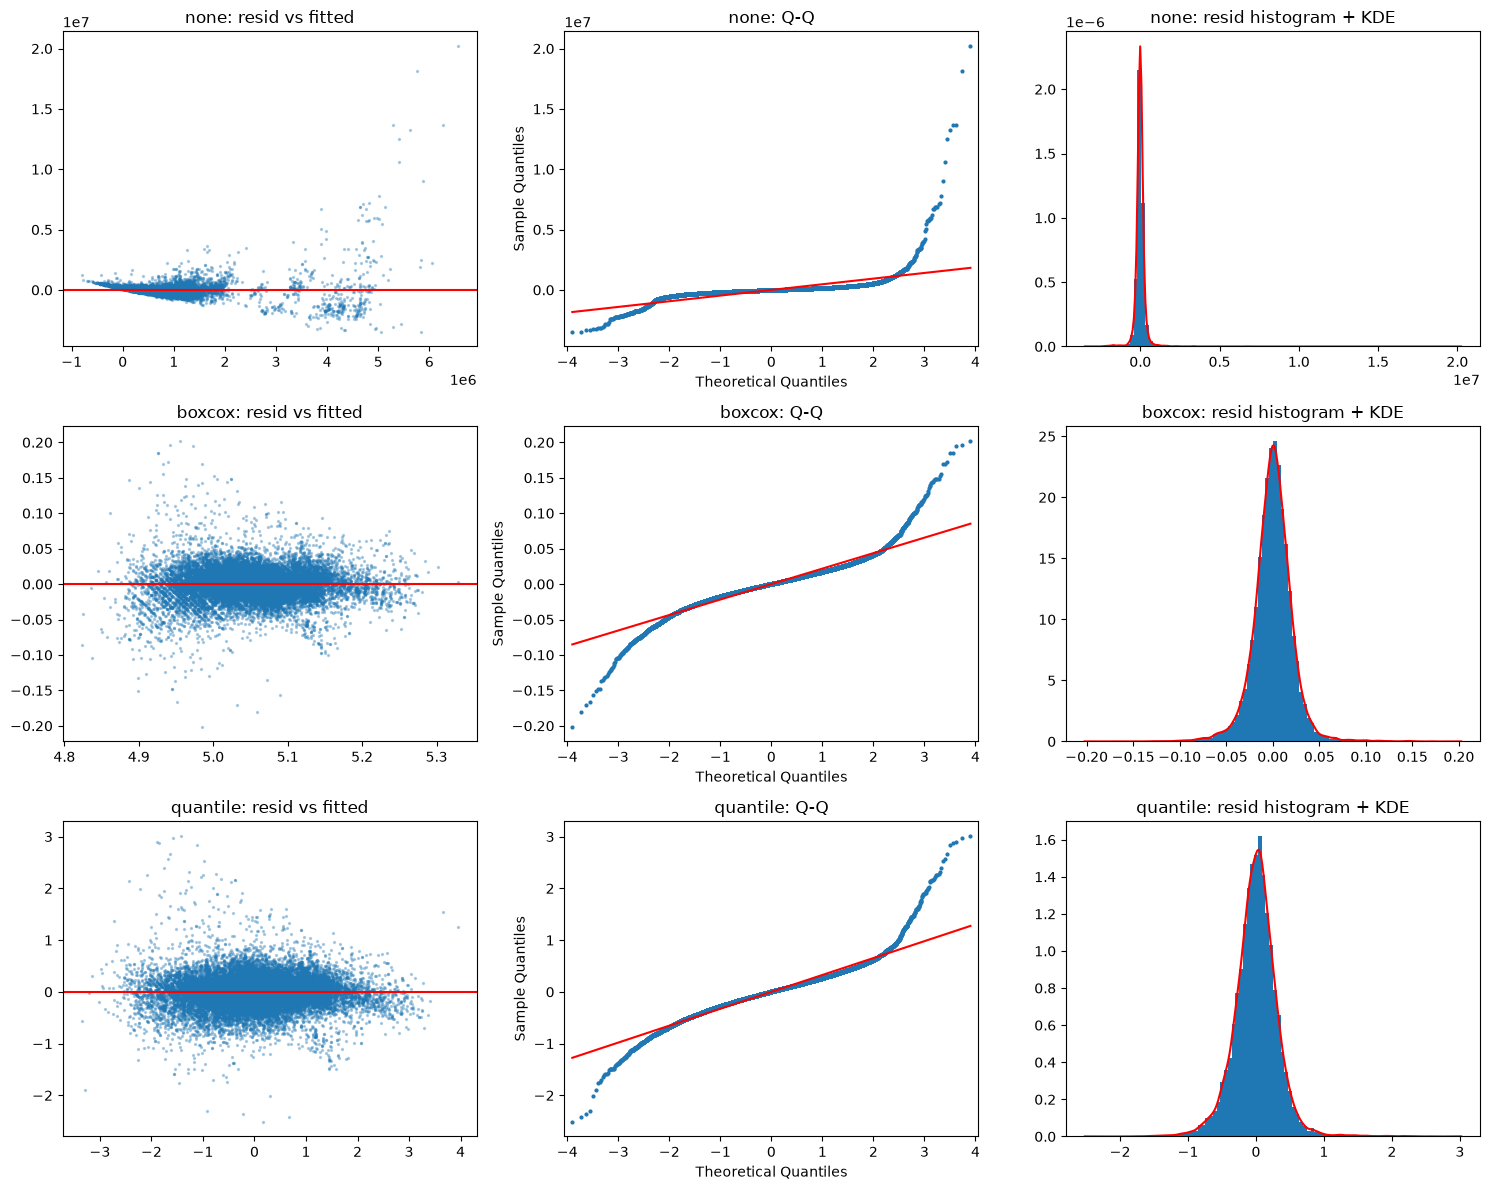

In [12]:
fig, ax = plt.subplots(len(C.TRANSFORMS), 3, figsize=(15, 4 * len(C.TRANSFORMS)))
for i, name in enumerate(C.TRANSFORMS):
    res = fits[name][0]
    ax[i, 0].scatter(res.fittedvalues, res.resid, s=2, alpha=.3); ax[i, 0].axhline(0, c="r"); ax[i, 0].set_title(f"{name}: resid vs fitted")
    sm.qqplot(res.resid, line="s", ax=ax[i, 1], markersize=2); ax[i, 1].set_title(f"{name}: Q-Q")
    ax[i, 2].hist(res.resid, bins=100, density=True)
    xs = np.linspace(res.resid.min(), res.resid.max(), 300); ax[i, 2].plot(xs, stats.gaussian_kde(res.resid)(xs), c="r")
    ax[i, 2].set_title(f"{name}: resid histogram + KDE")
plt.tight_layout(); plt.show()

## 8. Pick best transform (most assumptions passed, then lowest val RMSE) → evaluate test once

In [13]:
best = scores.sort_values(["assumptions_passed", "val_RMSE"], ascending=[False, True]).index[0]
res, fwd, inv = fits[best]
pred = inv(res.predict(X_te))
print("best transform:", best)
print(f"test RMSE={mean_squared_error(test[C.TARGET], pred) ** 0.5:,.0f}  MAE={mean_absolute_error(test[C.TARGET], pred):,.0f}  R2={r2_score(test[C.TARGET], pred):.4f}")
print("failed assumptions:"); print(results.query("transform == @best and not passed")[["assumption", "test"]].to_string(index=False))

best transform: boxcox
test RMSE=262,703  MAE=103,883  R2=0.8226
failed assumptions:
      assumption                         test
Homoscedasticity                Breusch-Pagan
Homoscedasticity  White (special form: ŷ, ŷ²)
       Normality           Kolmogorov-Smirnov
       Normality Shapiro-Wilk (all residuals)
       Normality                   Lilliefors


## 8a. Does each feature matter? Joint F-test per feature (best model, H0: all its coefficients = 0)

In [14]:
ft = []
for c in NUM + list(groups):
    cols = [c] if c in NUM else groups[c]
    R = np.zeros((len(cols), len(res.params))); R[range(len(cols)), [res.params.index.get_loc(k) for k in cols]] = 1
    t = res.f_test(R)
    ft.append(dict(feature=c, df=len(cols), F=float(np.squeeze(t.fvalue)), p_value=float(t.pvalue), significant=t.pvalue < C.ALPHA))
pd.DataFrame(ft).set_index("feature").round(4)

,df,F,p_value,significant
feature,,,,
engine_capacity,1,2238.8289,0.0,True
log_mileage,1,79.9299,0.0,True
car_age,1,48281.9158,0.0,True
model,122,293.6011,0.0,True
fuel_type,2,27.2733,0.0,True
gear_type,1,803.0739,0.0,True
color,15,15.6265,0.0,True


## 8b. Actual vs predicted (best transform, price scale)

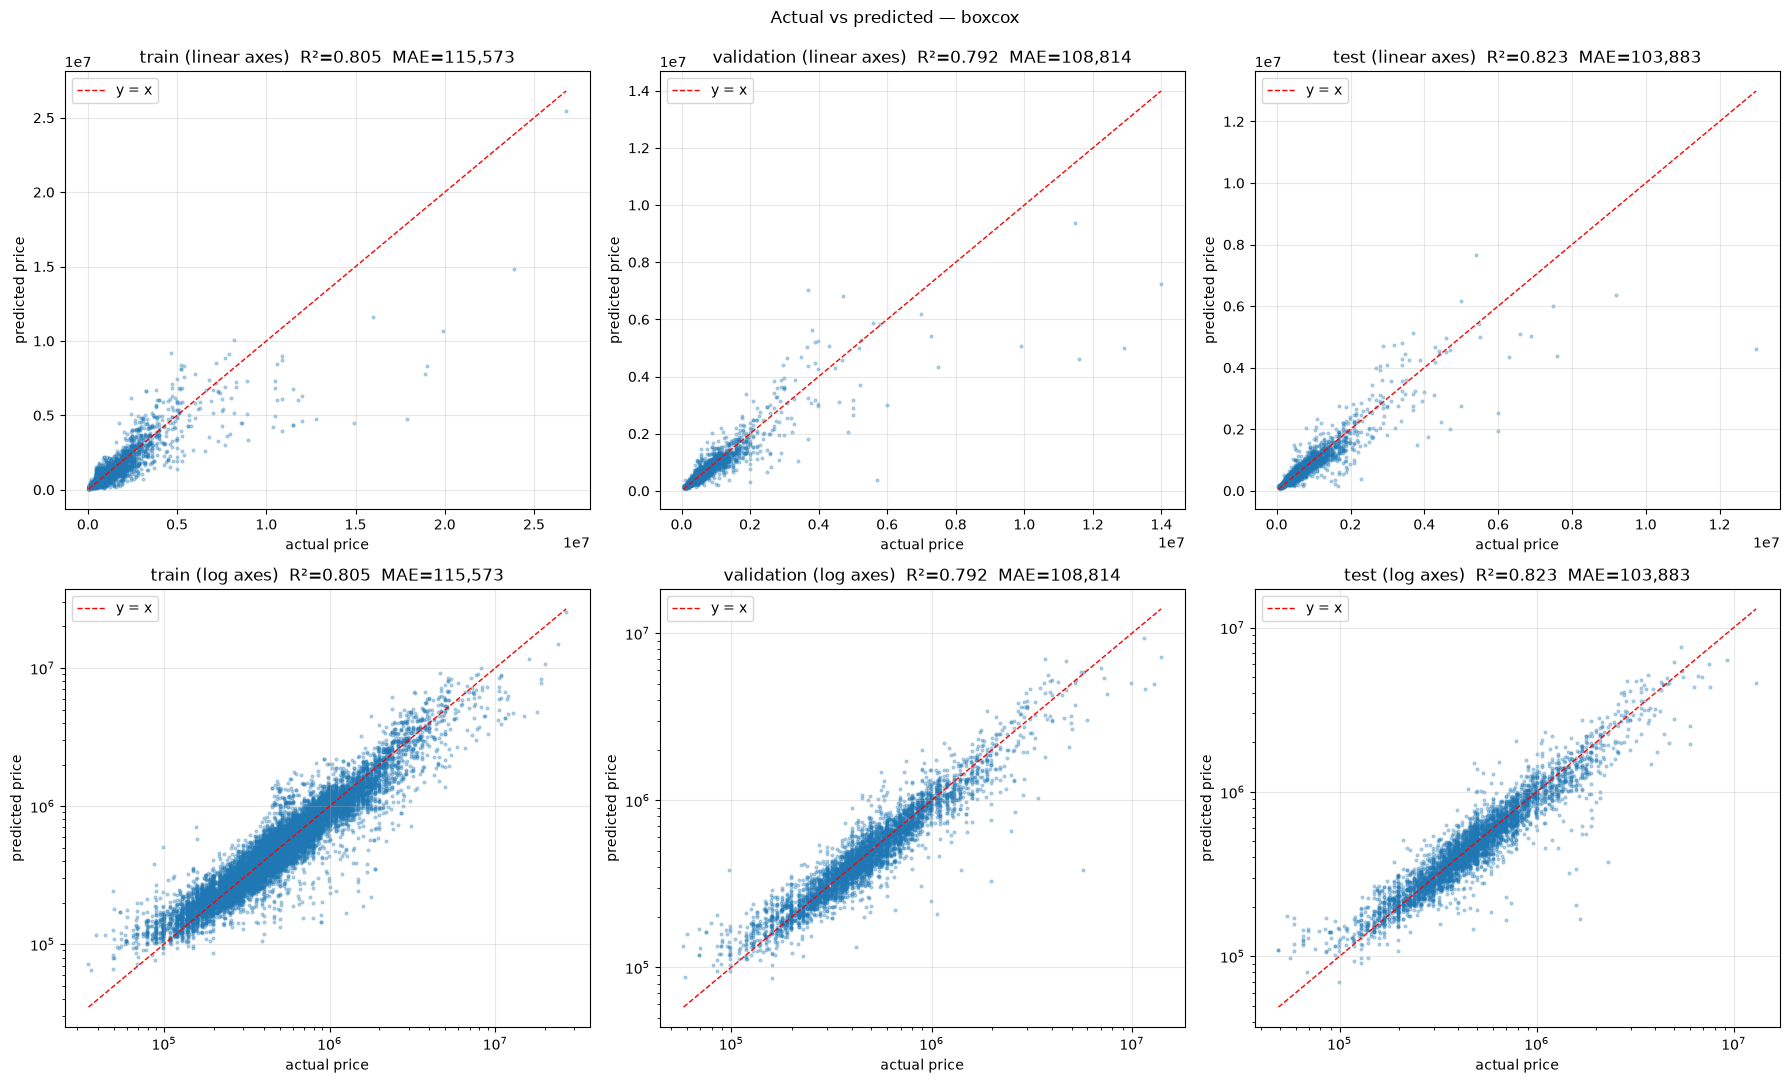

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(18, 11))
for j, (nm, d, X) in enumerate([("train", train, X_tr), ("validation", val, X_va), ("test", test, X_te)]):
    y, p = d[C.TARGET].values, inv(res.predict(X))
    r2, mae = r2_score(y, p), mean_absolute_error(y, p)
    for i, scale in enumerate(["linear", "log"]):
        a = ax[i, j]
        a.scatter(y, p, s=4, alpha=.3)
        lo, hi = min(y.min(), p.min()), max(y.max(), p.max())
        a.plot([lo, hi], [lo, hi], "r--", lw=1, label="y = x")
        a.set_xscale(scale); a.set_yscale(scale); a.grid(alpha=.3); a.legend()
        a.set_xlabel("actual price"); a.set_ylabel("predicted price")
        a.set_title(f"{nm} ({scale} axes)  R²={r2:.3f}  MAE={mae:,.0f}")
fig.suptitle(f"Actual vs predicted — {best}"); plt.tight_layout(); plt.show()

## 8c. Raw rows with the largest residuals (best model, train, standardized residual on the transformed scale)

In [16]:
TOP_N = 30
raw = pd.read_csv(C.DATA_PATH)          # original columns, same row index
z = res.resid / res.resid.std()
top = z.abs().nlargest(TOP_N).index
out = raw.loc[top].assign(model_used=train.loc[top, "model"], pred_price=inv(res.fittedvalues[top]).round(),
                          std_resid=z[top].round(2))
out["error"] = out["pred_price"] - out[C.TARGET]
print(f"|std resid| > 3: {(z.abs() > 3).sum()} rows ({100 * (z.abs() > 3).mean():.2f}% of train)")
out

|std resid| > 3: 312 rows (1.49% of train)


,brand,model,car_type,fuel_type,gear_type,color,engine_capacity,mileage,year,car_age,price,model_used,pred_price,std_resid,error
29269,SUBARU,IMPREZA,Hatchback,Benzine,Manual,Blue,2500,102500,2008,18,1590000,OTHER_BUDGET,188108.0,9.27,-1401892.0
6909,PROTON,PERSONA,Sedan,Benzine,Automatic,Brown,1600,135000,2012,14,49000,OTHER_BUDGET,242889.0,-9.25,193889.0
5460,MINI,JOHN COOPER WORK,Hatchback,Benzine,Manual,Sky Blue,1600,80000,2006,20,1250000,OTHER_MID,167351.0,9.01,-1082649.0
10582,MITSUBISHI,EVOLUTION,Sedan,Benzine,Automatic,White,2000,97500,2010,16,1790000,OTHER_MITSUBISHI,219493.0,8.89,-1570507.0
29454,MITSUBISHI,EVOLUTION,Sedan,Benzine,Automatic,White,2000,97500,2005,21,888000,OTHER_MITSUBISHI,144500.0,8.49,-743500.0
26068,MITSUBISHI,PAJERO,SUV,Benzine,Automatic,White,3500,207500,2001,25,890000,OTHER_MITSUBISHI,144936.0,8.48,-745064.0
6867,AUDI,A6,Sedan,Benzine,Automatic,Grey,2400,201000,2013,13,99000,OTHER_AUDI,501390.0,-8.25,402390.0
26005,MITSUBISHI,GALANT,Sedan,Benzine,Automatic,White,1800,122500,2007,19,890000,OTHER_MITSUBISHI,162257.0,7.87,-727743.0
25707,KIA,PICANTO,Hatchback,Benzine,Automatic,Red,1200,117500,2014,12,87000,OTHER_MID,383186.0,-7.81,296186.0
28609,NISSAN,CUBE,Hatchback,Benzine,Automatic,White,1500,102500,2009,17,799000,OTHER_NISSAN,153699.0,7.73,-645301.0


## 9. Which car `model` has the largest error? (best transform, validation set, price scale)

C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\346375789.py:20: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\346375789.py:20: UserWarning: Glyph 3606 (\N{THAI CHARACTER THO THUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\346375789.py:20: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\346375789.py:20: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\346375789.py:20: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\346375789.py

D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3606 (\N{THAI CHARACTER THO THUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io,

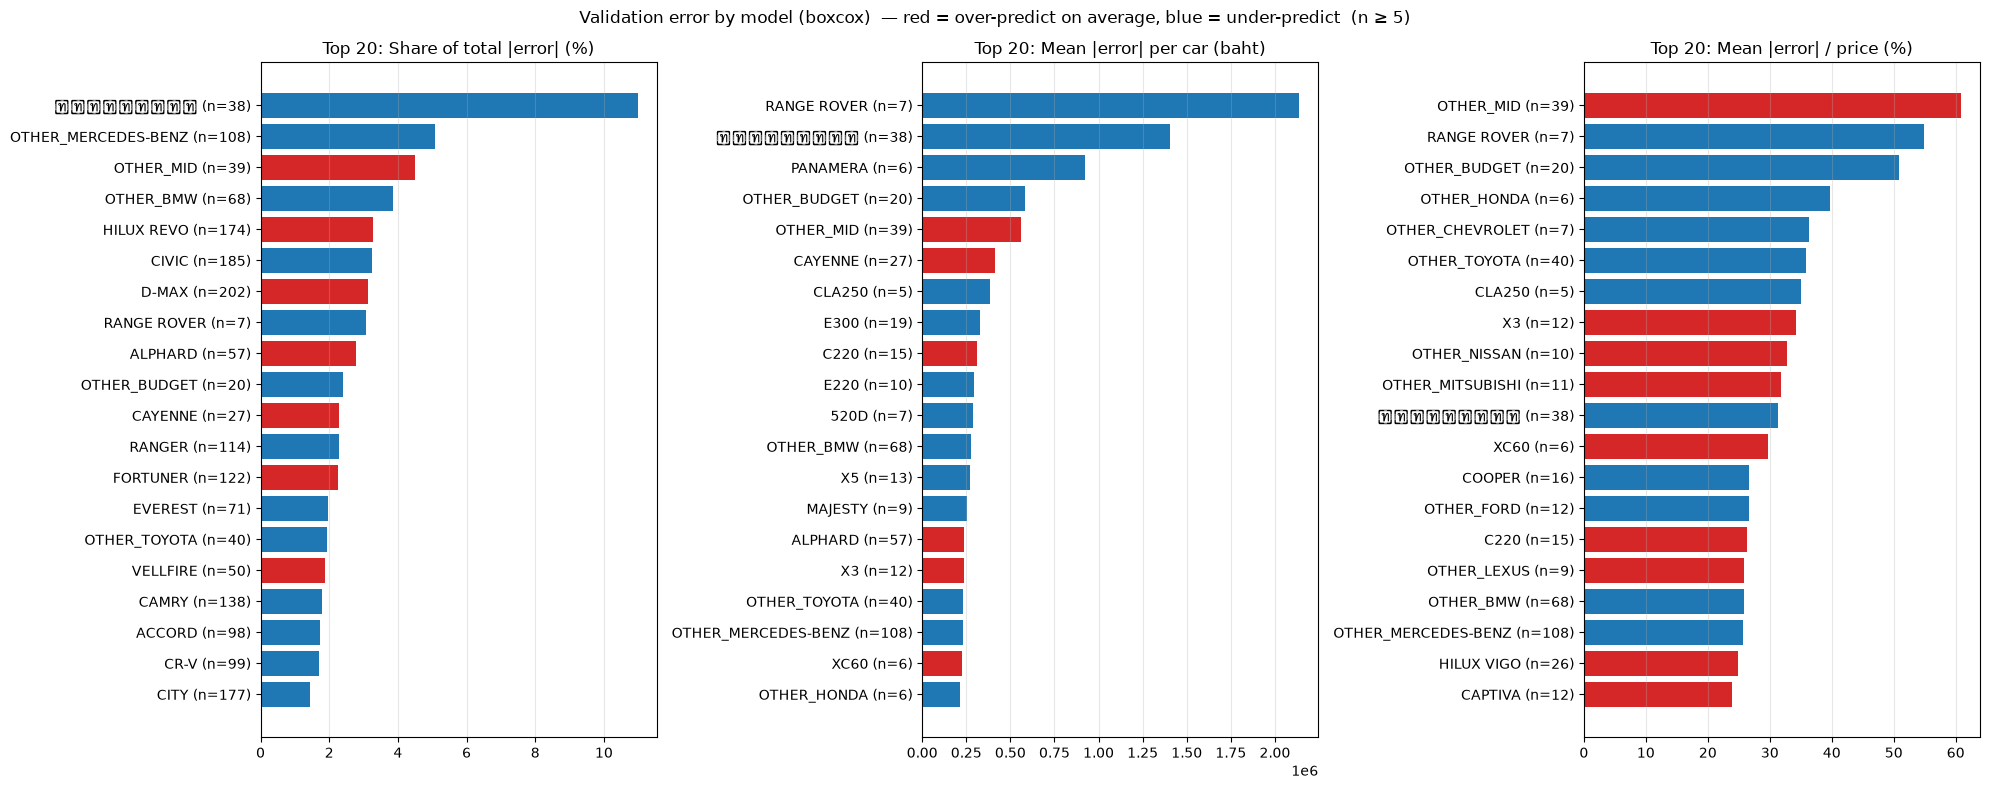

,n,MAE,bias,total_abs_err,mean_price,share_of_total_err_%,MAPE_%
model_grp,,,,,,,
รถราคาแพง,38,1406935.6,-328214.9,53463554.3,3994842.1,11.0,31.3
OTHER_MERCEDES-BENZ,108,229483.5,-124312.4,24784221.5,863694.4,5.1,25.6
OTHER_MID,39,559873.0,139388.9,21835048.3,955820.5,4.5,60.9
OTHER_BMW,68,275851.4,-114546.0,18757892.2,952058.8,3.9,25.8
HILUX REVO,174,91405.6,5359.2,15904572.6,487660.9,3.3,18.8
CIVIC,185,85197.6,-35951.5,15761553.6,547404.3,3.2,15.2
D-MAX,202,75252.6,14987.0,15201029.5,472707.9,3.1,17.4
RANGE ROVER,7,2139104.3,-393362.4,14973729.9,5288000.0,3.1,55.0
ALPHARD,57,236798.2,72910.9,13497495.8,1693701.8,2.8,13.5


In [17]:
res, fwd, inv = fits[best]
ev = val.assign(model_grp=val["model"],
                pred=inv(res.predict(X_va)))
ev["err"] = ev["pred"] - ev[C.TARGET]          # + = over-predict, - = under-predict
ev["abs_err"] = ev["err"].abs()
by = ev.groupby("model_grp").agg(n=("err", "size"), MAE=("abs_err", "mean"), bias=("err", "mean"),
                                 total_abs_err=("abs_err", "sum"), mean_price=(C.TARGET, "mean"))
by["share_of_total_err_%"] = 100 * by["total_abs_err"] / by["total_abs_err"].sum()
by["MAPE_%"] = 100 * ev.assign(ape=ev["abs_err"] / ev[C.TARGET]).groupby("model_grp")["ape"].mean()
TOP = 20
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
for a, col, title in [(ax[0], "share_of_total_err_%", "Share of total |error| (%)"),
                      (ax[1], "MAE", "Mean |error| per car (baht)"),
                      (ax[2], "MAPE_%", "Mean |error| / price (%)")]:
    t = by[by["n"] >= 5].nlargest(TOP, col)[::-1]
    a.barh([f"{m} (n={n})" for m, n in zip(t.index, t["n"])], t[col],
           color=np.where(t["bias"] > 0, "tab:red", "tab:blue"))
    a.set_title(f"Top {TOP}: {title}"); a.grid(axis="x", alpha=.3)
fig.suptitle(f"Validation error by model ({best})  — red = over-predict on average, blue = under-predict  (n ≥ 5)")
plt.tight_layout(); plt.show()
by.sort_values("total_abs_err", ascending=False).head(TOP).round(1)

C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\2067502251.py:5: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\2067502251.py:5: UserWarning: Glyph 3606 (\N{THAI CHARACTER THO THUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\2067502251.py:5: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\2067502251.py:5: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\2067502251.py:5: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\2067502251.p

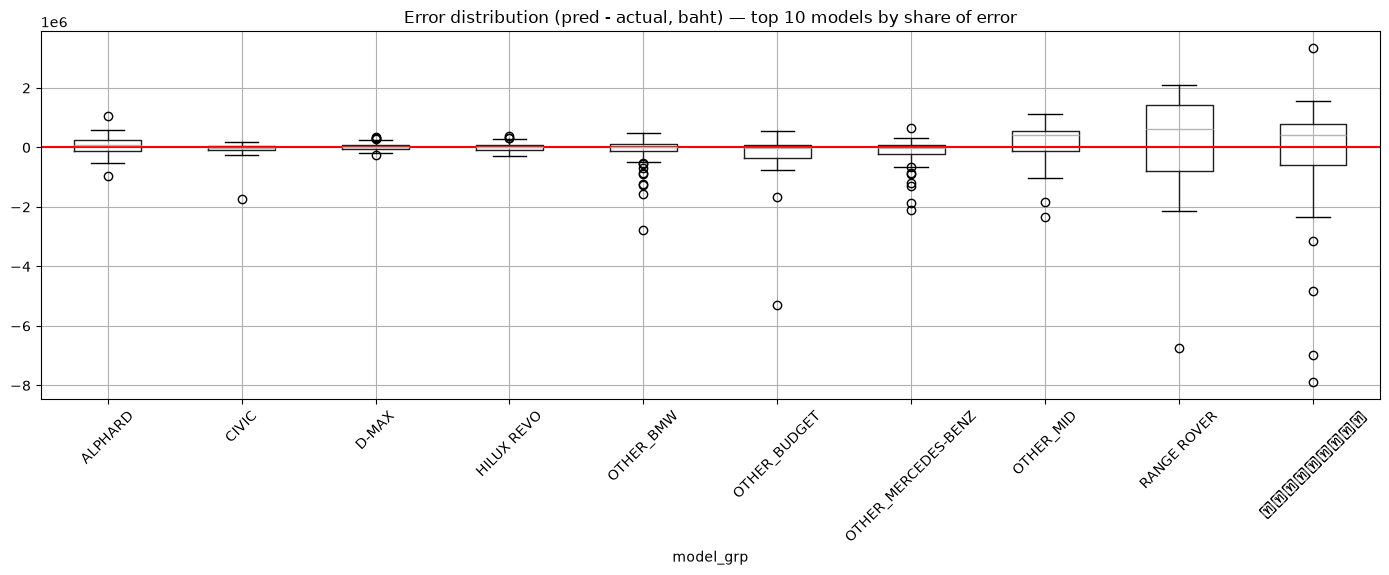

In [18]:
top = by[by["n"] >= 5].nlargest(10, "share_of_total_err_%").index
fig, ax = plt.subplots(figsize=(14, 6))
ev[ev["model_grp"].isin(top)].boxplot(column="err", by="model_grp", ax=ax, rot=45, showfliers=True)
ax.axhline(0, c="r"); ax.set_title("Error distribution (pred - actual, baht) — top 10 models by share of error"); fig.suptitle("")
plt.tight_layout(); plt.show()

## 10. Which **feature** carries the error? (best transform, train residuals)
- **Numeric:** mean residual per 20 quantile bins of the feature. A flat line at 0 means the linear term is fine. A curve means the feature is non-linear, which is what breaks Linearity.
- **η² (eta squared):** share of residual variance explained by the feature's bins/levels.
  - `η² resid` measures leftover mean structure (non-linearity), so it is always 0 for dummies already in the model.
  - `η² |resid|` measures variance that changes with the feature (heteroscedasticity).

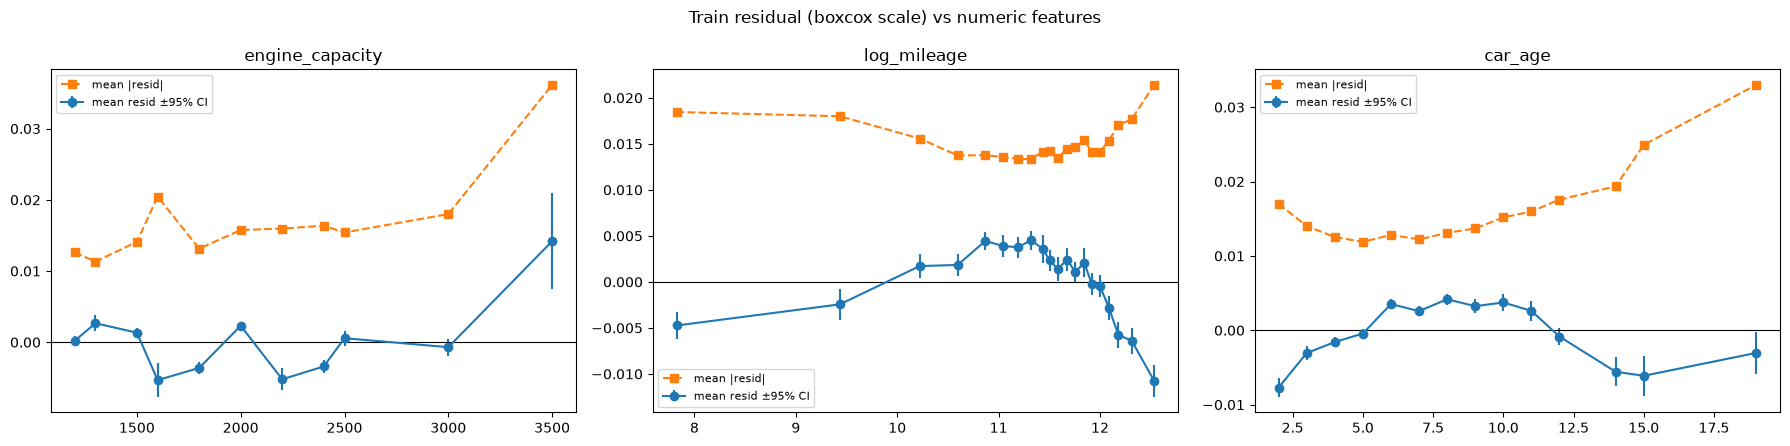

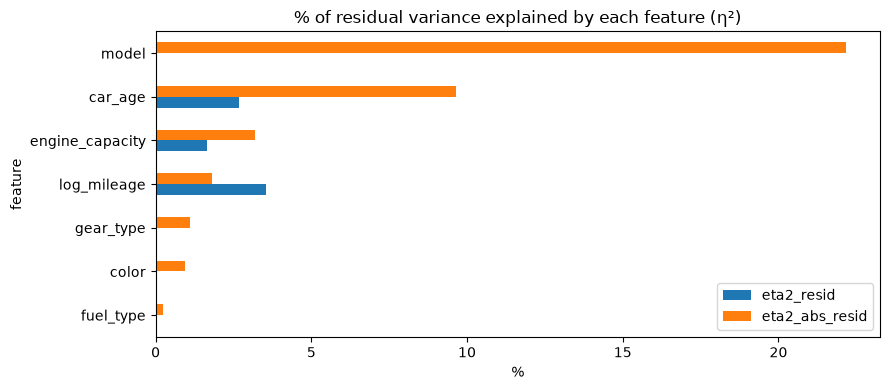

,eta2_resid,eta2_abs_resid
feature,,
fuel_type,0.00,0.24
color,0.00,0.94
gear_type,0.00,1.12
log_mileage,3.54,1.80
engine_capacity,1.64,3.19
car_age,2.67,9.64
model,0.00,22.15


In [19]:
res = fits[best][0]
tr = train.loc[res.resid.index].assign(resid=res.resid, abs_resid=res.resid.abs(),
                  color=train["color"].where(train["color"].isin(levels["color"]), C.RARE_LABEL["color"]))
def eta2(y, g):
    m = y.groupby(g).transform("mean"); return ((m - y.mean()) ** 2).sum() / ((y - y.mean()) ** 2).sum()
fig, ax = plt.subplots(1, len(NUM), figsize=(18, 4.5)); rows = []
for a, c in zip(ax, NUM):
    b = pd.qcut(tr[c], 20, duplicates="drop")
    s = tr.groupby(b, observed=True).agg(x=(c, "median"), m=("resid", "mean"), se=("resid", "sem"), mae=("abs_resid", "mean"))
    a.errorbar(s["x"], s["m"], yerr=1.96 * s["se"], marker="o", label="mean resid ±95% CI"); a.axhline(0, c="k", lw=.8)
    a.plot(s["x"], s["mae"], "s--", c="tab:orange", label="mean |resid|"); a.set_title(c); a.legend(fontsize=8)
    rows.append(dict(feature=c, eta2_resid=eta2(tr["resid"], b), eta2_abs_resid=eta2(tr["abs_resid"], b)))
plt.suptitle(f"Train residual ({best} scale) vs numeric features"); plt.tight_layout(); plt.show()
for c in C.CAT_COLS:
    rows.append(dict(feature=c, eta2_resid=eta2(tr["resid"], tr[c]), eta2_abs_resid=eta2(tr["abs_resid"], tr[c])))
feat = pd.DataFrame(rows).set_index("feature").sort_values("eta2_abs_resid")
feat.mul(100).plot.barh(figsize=(9, 4), title="% of residual variance explained by each feature (η²)"); plt.xlabel("%"); plt.tight_layout(); plt.show()
feat.mul(100).round(2)

## 11. Deep-dive: `model` — error inside the `OTHER_*` fallback groups, and model-name consistency
`brand` is dropped from X; it is used here only to diagnose the problem.

OTHER_* groups: 377 val rows (8.4%) -> 19.6% of total |error|


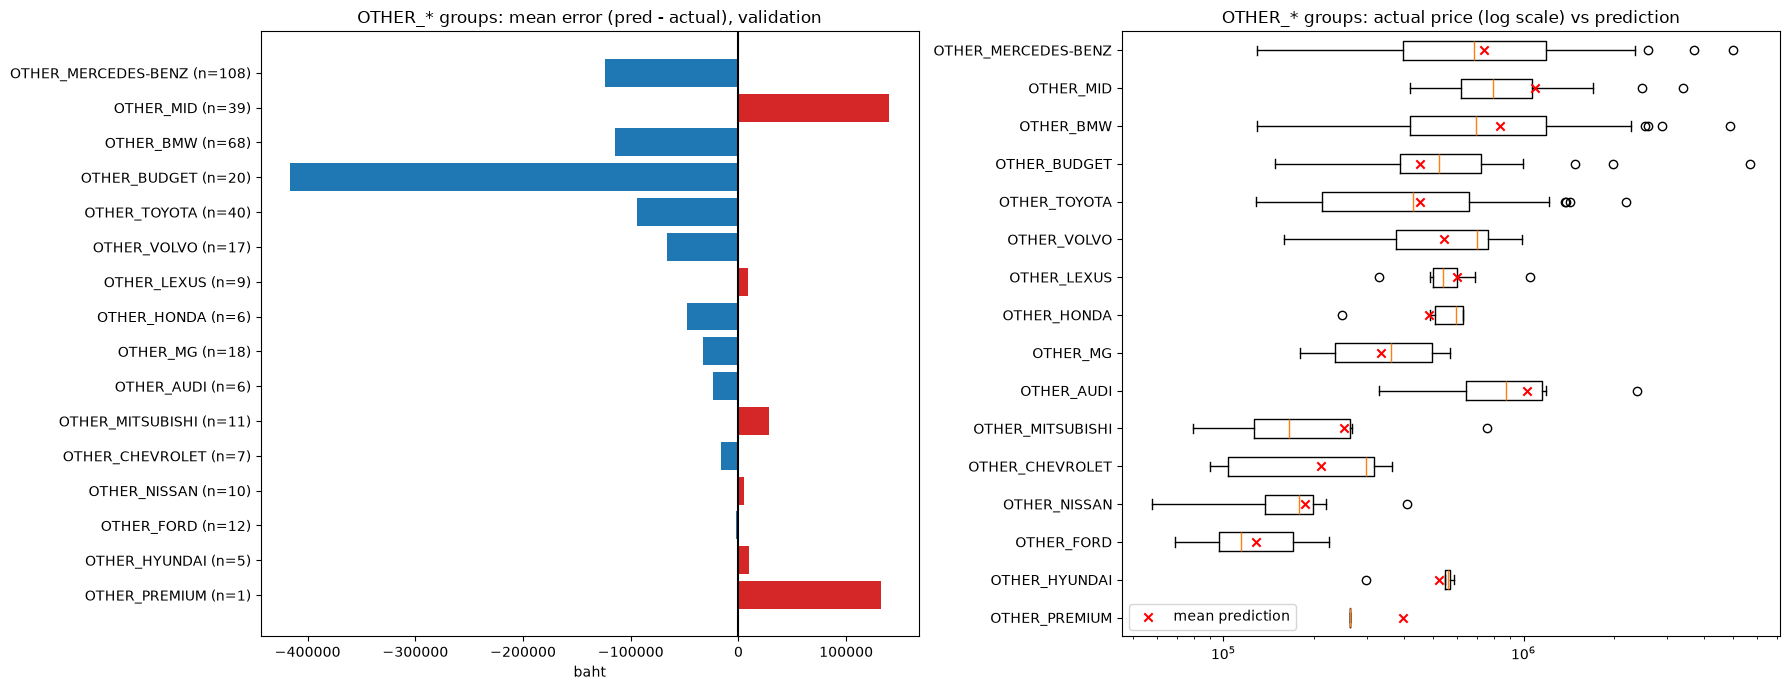

,n,brands,models,med_price,mean_pred,bias,total_abs_err,share_of_all_val_err_%
model_grp,,,,,,,,
OTHER_MERCEDES-BENZ,108,1,31,684000.0,739382.0,-124312.0,24784221.0,5.0
OTHER_MID,39,9,15,790000.0,1095209.0,139389.0,21835048.0,4.0
OTHER_BMW,68,1,26,693500.0,837513.0,-114546.0,18757892.0,4.0
OTHER_BUDGET,20,9,15,524000.0,452929.0,-415921.0,11685537.0,2.0
OTHER_TOYOTA,40,1,13,429500.0,450919.0,-94203.0,9356270.0,2.0
OTHER_VOLVO,17,1,4,699000.0,543034.0,-66495.0,2118536.0,0.0
OTHER_LEXUS,9,1,8,540000.0,600121.0,8676.0,1304963.0,0.0
OTHER_HONDA,6,1,3,597000.0,484493.0,-47340.0,1272674.0,0.0
OTHER_MG,18,1,5,362000.0,335913.0,-33253.0,1249849.0,0.0


In [20]:
oth = ev[ev["model_grp"].str.startswith("OTHER")]
b = oth.groupby("model_grp").agg(n=("err", "size"), brands=("brand", "nunique"), models=("model_clean", "nunique"),
                                 med_price=(C.TARGET, "median"), mean_pred=("pred", "mean"), bias=("err", "mean"),
                                 total_abs_err=("abs_err", "sum")).sort_values("total_abs_err", ascending=False)
b["share_of_all_val_err_%"] = 100 * b["total_abs_err"] / ev["abs_err"].sum()
print(f"OTHER_* groups: {len(oth)} val rows ({100 * len(oth) / len(ev):.1f}%) -> {b['share_of_all_val_err_%'].sum():.1f}% of total |error|")
t = b.head(20)[::-1]
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
ax[0].barh(t.index + " (n=" + t["n"].astype(str) + ")", t["bias"], color=np.where(t["bias"] > 0, "tab:red", "tab:blue"))
ax[0].axvline(0, c="k"); ax[0].set_title("OTHER_* groups: mean error (pred - actual), validation"); ax[0].set_xlabel("baht")
ax[1].boxplot([oth.loc[oth["model_grp"] == g, C.TARGET] for g in t.index], orientation="horizontal", tick_labels=t.index)
ax[1].scatter(t["mean_pred"], range(1, len(t) + 1), marker="x", c="r", zorder=3, label="mean prediction")
ax[1].set_xscale("log"); ax[1].set_title("OTHER_* groups: actual price (log scale) vs prediction"); ax[1].legend()
plt.tight_layout(); plt.show()
b.round(0)

### Model-name consistency: same car spelled differently, or mixed granularity (series vs trim)

In [21]:
import re
norm = lambda s: re.sub(r"[^A-Z0-9]", "", s.upper())
g = df.groupby(["brand", "model"]).agg(n=(C.TARGET, "size"), med_price=(C.TARGET, "median"), med_age=("car_age", "median")).reset_index()
g["key"] = g["model"].map(norm)
print("Same name after removing spaces/hyphens (should be empty after cleanup):")
display(g[g.duplicated(["brand", "key"], keep=False)].drop(columns="key"))
print("Series-level label mixed with trim-level labels (e.g. C-CLASS vs C200/C220):")
display(g[g["model"].str.contains(r"^(?:C|E|S)-CLASS$|^C2\d\d$|^E[23]\d\d$|ALTIS|NAVARA|HILUX VIGO", regex=True)].sort_values("model"))

Same name after removing spaces/hyphens (should be empty after cleanup):


,brand,model,n,med_price,med_age


Series-level label mixed with trim-level labels (e.g. C-CLASS vs C200/C220):


,brand,model,n,med_price,med_age,key
354,NISSAN,BIG-M FRONTIER NAVARA,2,179000.0,15.5,BIGMFRONTIERNAVARA
227,MERCEDES-BENZ,C-CLASS,30,539000.0,9.0,CCLASS
230,MERCEDES-BENZ,C200,49,328000.0,14.0,C200
232,MERCEDES-BENZ,C220,94,1490000.0,4.0,C220
234,MERCEDES-BENZ,C230,6,259500.0,17.0,C230
236,MERCEDES-BENZ,C250,10,399000.0,13.5,C250
427,TOYOTA,COROLLA ALTIS,855,419000.0,7.0,COROLLAALTIS
249,MERCEDES-BENZ,E-CLASS,46,499000.0,11.0,ECLASS
250,MERCEDES-BENZ,E200,47,388000.0,14.0,E200
252,MERCEDES-BENZ,E220,54,1394500.0,7.0,E220


## 12. One model per brand group
A separate OLS is fitted for each brand group on that group's train rows. Every group uses the same features **minus the brand dummy**, since brand is constant within a group.
- Features listed in `PB_DROP` are removed from the per-brand models. Inside one brand, `model` already fixes engine size and fuel, so keeping them makes VIF high.
- With `GROUP_BY = "model"`, the segments are **brands** (< RARE_MIN train rows → OTHER), and the model group is a feature inside each brand.
- Within each segment, categorical levels with < RARE_MIN train rows, or unseen in train, share one `_RARE` dummy. The most frequent level is the reference.
- The same assumption tests and transforms as above are used. The transform is fitted per group, so each group gets its own Box-Cox λ.

In [22]:
if C.GROUP_BY == "model":   # segment = brand (< RARE_MIN train rows -> OTHER); model group stays a feature inside each brand
    bc = train["brand"].value_counts(); seg_keep = set(bc[bc >= C.RARE_MIN].index)
    seg = lambda d: d["brand"].where(d["brand"].isin(seg_keep), "OTHER")
    PB_CATS = [c for c in C.CAT_COLS if c not in C.PB_DROP]
else:                         # segment = brand group already stored in "model"
    seg = lambda d: d["model"]
    PB_CATS = [c for c in C.CAT_COLS if c != "model" and c not in C.PB_DROP]
PB_NUM = [c for c in NUM if c not in C.PB_DROP]
print("per-brand features:", PB_NUM + PB_CATS, "| dropped:", C.PB_DROP)

def brand_design(d, lv):
    X = d[PB_NUM].astype(float).copy()
    for c, levs in lv.items():
        s_ = d[c].where(d[c].isin(levs), "_RARE" if "_RARE" in levs else levs[0])
        X = X.join(pd.get_dummies(pd.Categorical(s_, categories=levs), prefix=c, drop_first=True, dtype=float).set_index(d.index))
    return sm.add_constant(X, has_constant="add")

def vif_rows(X):
    out = []
    for c in PB_NUM + PB_CATS:
        cols = [c] if c in PB_NUM else [k for k in X.columns if k.startswith(c + "_")]
        if not cols:
            continue
        v = max(variance_inflation_factor(X.values, X.columns.get_loc(k)) for k in cols)
        out.append(row("Multicollinearity", f"VIF {c}", v, np.nan, f"< {C.VIF_MAX}", v < C.VIF_MAX))
    return out

pb_tests, pb_scores, pb_pred = [], [], {t: pd.Series(index=val.index, dtype=float) for t in C.TRANSFORMS}
for b, tr_b in train.groupby(seg(train)):
    va_b = val[seg(val) == b]
    lv = {}
    for c in PB_CATS:
        vc = tr_b[c].value_counts()
        lv[c] = vc[vc >= C.RARE_MIN].index.tolist() or [vc.index[0]]
        if len(lv[c]) < len(vc):
            lv[c].append("_RARE")   # levels with < RARE_MIN rows in this segment (and unseen ones) share one dummy
    Xb = brand_design(tr_b, lv)
    for t in C.TRANSFORMS:
        fwd_b, inv_b = make_transform(t, tr_b[C.TARGET])
        r_b = sm.OLS(fwd_b(tr_b[C.TARGET]), Xb).fit()
        pb_tests += [dict(brand=b, transform=t, **x) for x in residual_tests(r_b, Xb) + vif_rows(Xb)]
        z_b, zt = r_b.predict(brand_design(va_b, lv)[Xb.columns]), fwd_b(tr_b[C.TARGET])
        # ponytail: clip to the train range of transformed y, else Box-Cox (λ<0) inverse returns NaN/inf past its asymptote
        n_clip = int(((z_b < zt.min()) | (z_b > zt.max())).sum())
        p_b = inv_b(np.clip(z_b, zt.min(), zt.max()))
        pb_pred[t].loc[va_b.index] = p_b
        pb_scores.append(dict(brand=b, transform=t, n_train=len(tr_b), n_val=len(va_b), n_cols=Xb.shape[1], n_val_clipped=n_clip, train_R2=r_b.rsquared,
                              val_R2=r2_score(va_b[C.TARGET], p_b) if len(va_b) > 1 else np.nan,
                              val_MAE=mean_absolute_error(va_b[C.TARGET], p_b) if len(va_b) else np.nan))
pb_tests, pb_scores = pd.DataFrame(pb_tests), pd.DataFrame(pb_scores)
pb_scores = pb_scores.merge(pb_tests.groupby(["brand", "transform"])["passed"].agg(passed="sum", total="size").reset_index(), on=["brand", "transform"])
print("ALL brands pooled (validation, price scale) vs single model:")
for t in C.TRANSFORMS:
    p_ = pb_pred[t]
    print(f"  {t:7s} per-brand: R2={r2_score(val[C.TARGET], p_):.3f}  MAE={mean_absolute_error(val[C.TARGET], p_):,.0f}   |  single model: "
          f"R2={scores.loc[t, 'val_R2']:.3f}  MAE={scores.loc[t, 'val_MAE']:,.0f}")
pb_scores.set_index(["brand", "transform"])[["n_train", "n_val", "passed", "total", "train_R2", "val_R2", "val_MAE", "n_val_clipped"]].round(3)

per-brand features: ['engine_capacity', 'log_mileage', 'car_age', 'model', 'fuel_type', 'gear_type', 'color'] | dropped: []
boxcox lambda = 0.0723


boxcox lambda = -0.0449
boxcox lambda = 0.3137


boxcox lambda = 0.4226
boxcox lambda = -0.7095


C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\556963051.py:40: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_b = sm.OLS(fwd_b(tr_b[C.TARGET]), Xb).fit()
D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\statsmodels\stats\diagnostic.py:1217: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y, x).fit()
C:\Users\putaw\AppData\Local\Temp\ipykernel_21360\556963051.py:24: UserWarning: The design matrix is poorly conditioned (condition number=6.51e+19). VIF calculations may be numerically unstable.
  v = max(variance_inflation_factor(X.values, X.columns.get_loc(k)) for k in cols)
D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:2018: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr / self.centered

boxcox lambda = 0.3738


...

boxcox lambda = -0.0695


D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6378.
  res = hypotest_fun_out(*samples, **kwds)


D:\.tawan_obsidian\.Hermes_docker(vault)\in_docker\RW\new_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6378.
  res = hypotest_fun_out(*samples, **kwds)


boxcox lambda = 0.1202
boxcox lambda = 0.1573
ALL brands pooled (validation, price scale) vs single model:
  none    per-brand: R2=0.798  MAE=120,700   |  single model: R2=0.670  MAE=174,317
  boxcox  per-brand: R2=0.831  MAE=96,319   |  single model: R2=0.792  MAE=108,814
  quantile per-brand: R2=0.823  MAE=97,668   |  single model: R2=0.754  MAE=113,556


n_train  n_val  passed  total  train_R2  val_R2      val_MAE  n_val_clipped
brand         transform                                                                             
AUDI          none            92     10       7     12     0.840   0.826   378008.886              0
              boxcox          92     10      10     12     0.869   0.733   317369.562              0
              quantile        92     10       7     12     0.805   0.152   476699.120              0
BMW           none           980    220       7     12     0.747   0.765   238313.505             10
              boxcox         980    220       8     12     0.886   0.805   186938.227              0
              quantile       980    220       7     12     0.877   0.811   183855.928              0
CHEVROLET     none           109     26       9     13     0.714   0.564    62878.459              0
              boxcox         109     26      10     13     0.811   0.598    60395.981              0
              quantile       109     26       9     13     0.790   0.560    63822.357              0
FORD          none           840    197       8     13     0.773   0.784   112468.070              2
              boxcox         840    197       8     13     0.844   0.814    99903.394              1
              quantile       840    197       8     13     0.825   0.843    92529.585              0
HAVAL         none            61      4       9     11     0.194  -1.618    43932.151              0
              boxcox          61      4      10     11     0.209  -1.356    41849.614              0
              quantile        61      4       7     11     0.121  -1.443    42011.803              0
HONDA         none          3726    834       8     13     0.822   0.771    65230.101             11
              boxcox        3726    834       8     13     0.876   0.805    56824.707              0
              quantile      3726    834       8     13     0.874   0.797    57558.713              0
HYUNDAI       none           328     63       5     13     0.842   0.797    87712.958              0
              boxcox         328     63       8     13     0.863   0.803    82647.103              0
              quantile       328     63       6     13     0.829   0.802    82829.446              0
ISUZU         none          1249    271       9     13     0.786   0.803    76236.506              7
              boxcox        1249    271      12     13     0.838   0.840    68359.872              0
              quantile      1249    271      10     13     0.823   0.850    65947.675              0
KIA           none            65     12      10     12     0.833   0.762   134824.544              0
              boxcox          65     12      10     12     0.867   0.777   123841.336              0
              quantile        65     12       8     12     0.703   0.814   111499.935              0
LAND ROVER    none            56     11       8     12     0.693   0.636  1709127.308              2
              boxcox          56     11      12     12     0.865   0.666  1565591.777              0
              quantile        56     11       8     12     0.743   0.702  1549887.561              0
LEXUS         none            77     11       7     12     0.844   0.854   299588.735              2
              boxcox          77     11      10     12     0.909   0.887   244802.475              0
              quantile        77     11       8     12     0.760   0.939   168850.844              0
MAZDA         none          1427    300       7     13     0.858   0.873    43929.088              1
              boxcox        1427    300       9     13     0.883   0.884    42425.501              0
              quantile      1427    300       8     13     0.870   0.892    41188.031              0
MERCEDES-BENZ none          1375    270       7     12     0.685   0.668   340258.557             16
              boxcox        1375    270       8     12     0.893   0.734   264876.823 

### Pass/fail per brand group

In [23]:
for t in C.TRANSFORMS:
    m_ = pb_tests[pb_tests["transform"] == t].pivot_table(index=["assumption", "test"], columns="brand", values="passed", aggfunc="first")
    print(f"=== {t} ===")
    display(m_.astype(object).replace({True: "✓", False: "✗"}).fillna("–"))   # – = feature has a single level in that brand

=== none ===


brand                                          AUDI BMW CHEVROLET FORD HAVAL HONDA HYUNDAI ISUZU KIA LAND ROVER LEXUS MAZDA MERCEDES-BENZ MG MINI MITSUBISHI NISSAN OTHER PORSCHE SUBARU SUZUKI  \
assumption        test                                                                                                                                                                            
Homoscedasticity  Breusch-Pagan                   ✗   ✗         ✗    ✗     ✓     ✗       ✗     ✗   ✗          ✗     ✗     ✗             ✗  ✗    ✗          ✗      ✗     ✗       ✗      ✗      ✗   
                  White (special form: ŷ, ŷ²)     ✗   ✗         ✗    ✗     ✓     ✗       ✗     ✗   ✗          ✗     ✗     ✗             ✗  ✗    ✗          ✓      ✗     ✗       ✗      ✗      ✗   
Independence      Durbin-Watson                   ✓   ✓         ✓    ✓     ✗     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
Multicollinearity VIF car_age                     ✓   ✓         ✓    ✓     ✓     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
                  VIF color                       ✓   ✓         ✓    ✓     ✓     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
                  VIF engine_capacity             ✓   ✓         ✓    ✓     ✓     ✓       ✗     ✓   ✓          ✓     ✓     ✗             ✓  ✓    ✓          ✗      ✗     ✓       ✓      ✓      ✓   
                  VIF fuel_type                   ✓   ✓         ✓    ✓     –     ✓       ✗     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✗      ✗     ✓       ✓      ✓      ✓   
                  VIF gear_type                   –   –         ✓    ✓     –     ✓       ✓     ✓   –          –     –     ✓             –  ✓    ✓          ✓      ✓     ✓       –      ✓      ✓   
                  VIF log_mileage                 ✓   ✓         ✓    ✓     ✓     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
                  VIF model                       ✓   ✓         ✓    ✓     ✓     ✓       ✗     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✗      ✗     ✓       ✗      ✓      ✓   
Normality         Kolmogorov-Smirnov              ✗   ✗         ✓    ✗     ✓     ✗       ✗     ✓   ✓          ✓     ✗     ✗             ✗  ✓    ✓          ✗      ✗     ✗       ✗      ✓      ✗   
                  Lilliefors                      ✗   ✗         ✗    ✗     ✓     ✗       ✗     ✗   ✓          ✗     ✗     ✗             ✗  ✓    ✗          ✗      ✗     ✗       ✗      ✗      ✗   
                  Shapiro-Wilk (all residuals)    ✗   ✗         ✗    ✗     ✗     ✗       ✗     ✗   ✓          ✗     ✗     ✗             ✗  ✗    ✗          ✗      ✗     ✗       ✗      ✗      ✗   

brand                                          TOYOTA VOLKSWAGEN VOLVO  
assumption        test                                                  
Homoscedasticity  Breusch-Pagan                     ✗          ✗     ✗  
                  White (special form: ŷ, ŷ²)       ✗          ✗     ✗  
Independence      Durbin-Watson                     ✓          ✓     ✓  
Multicollinearity VIF car_age                       ✓          ✓     ✓  
                  VIF color                         ✓          ✓     ✓  
                  VIF engine_capacity               ✗          ✓     ✓  
                  VIF fuel_type                     ✗          ✓     ✓  
                  VIF gear_type                     ✓          –     –  
                  VIF log_mileage                   ✓          ✓     ✓  
                  VIF model                         ✗          ✓     ✓  
Normality         Kolmogorov-Smirnov                ✗          ✓     ✗  
                  Lilliefors                        ✗          ✓     ✗  
                  Shapiro-Wilk (all residuals)      

=== boxcox ===


brand                                          AUDI BMW CHEVROLET FORD HAVAL HONDA HYUNDAI ISUZU KIA LAND ROVER LEXUS MAZDA MERCEDES-BENZ MG MINI MITSUBISHI NISSAN OTHER PORSCHE SUBARU SUZUKI  \
assumption        test                                                                                                                                                                            
Homoscedasticity  Breusch-Pagan                   ✓   ✗         ✗    ✗     ✓     ✗       ✓     ✗   ✗          ✓     ✗     ✗             ✗  ✗    ✗          ✗      ✗     ✓       ✗      ✗      ✗   
                  White (special form: ŷ, ŷ²)     ✓   ✗         ✓    ✗     ✓     ✗       ✗     ✓   ✗          ✓     ✗     ✗             ✗  ✗    ✓          ✗      ✗     ✓       ✓      ✗      ✗   
Independence      Durbin-Watson                   ✓   ✓         ✓    ✓     ✗     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
Multicollinearity VIF car_age                     ✓   ✓         ✓    ✓     ✓     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
                  VIF color                       ✓   ✓         ✓    ✓     ✓     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
                  VIF engine_capacity             ✓   ✓         ✓    ✓     ✓     ✓       ✗     ✓   ✓          ✓     ✓     ✗             ✓  ✓    ✓          ✗      ✗     ✓       ✓      ✓      ✓   
                  VIF fuel_type                   ✓   ✓         ✓    ✓     –     ✓       ✗     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✗      ✗     ✓       ✓      ✓      ✓   
                  VIF gear_type                   –   –         ✓    ✓     –     ✓       ✓     ✓   –          –     –     ✓             –  ✓    ✓          ✓      ✓     ✓       –      ✓      ✓   
                  VIF log_mileage                 ✓   ✓         ✓    ✓     ✓     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
                  VIF model                       ✓   ✓         ✓    ✓     ✓     ✓       ✗     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✗      ✗     ✓       ✗      ✓      ✓   
Normality         Kolmogorov-Smirnov              ✓   ✓         ✓    ✗     ✓     ✗       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✗      ✗     ✓       ✓      ✓      ✗   
                  Lilliefors                      ✗   ✗         ✗    ✗     ✓     ✗       ✓     ✓   ✓          ✓     ✓     ✓             ✗  ✓    ✗          ✗      ✗     ✓       ✓      ✓      ✗   
                  Shapiro-Wilk (all residuals)    ✗   ✗         ✗    ✗     ✓     ✗       ✗     ✓   ✓          ✓     ✓     ✗             ✗  ✗    ✗          ✗      ✗     ✓       ✗      ✗      ✗   

brand                                          TOYOTA VOLKSWAGEN VOLVO  
assumption        test                                                  
Homoscedasticity  Breusch-Pagan                     ✗          ✓     ✗  
                  White (special form: ŷ, ŷ²)       ✗          ✓     ✗  
Independence      Durbin-Watson                     ✓          ✓     ✓  
Multicollinearity VIF car_age                       ✓          ✓     ✓  
                  VIF color                         ✓          ✓     ✓  
                  VIF engine_capacity               ✗          ✓     ✓  
                  VIF fuel_type                     ✗          ✓     ✓  
                  VIF gear_type                     ✓          –     –  
                  VIF log_mileage                   ✓          ✓     ✓  
                  VIF model                         ✗          ✓     ✓  
Normality         Kolmogorov-Smirnov                ✗          ✓     ✓  
                  Lilliefors                        ✗          ✓     ✗  
                  Shapiro-Wilk (all residuals)      

=== quantile ===


brand                                          AUDI BMW CHEVROLET FORD HAVAL HONDA HYUNDAI ISUZU KIA LAND ROVER LEXUS MAZDA MERCEDES-BENZ MG MINI MITSUBISHI NISSAN OTHER PORSCHE SUBARU SUZUKI  \
assumption        test                                                                                                                                                                            
Homoscedasticity  Breusch-Pagan                   ✗   ✗         ✗    ✗     ✓     ✗       ✓     ✗   ✗          ✓     ✓     ✗             ✗  ✗    ✗          ✗      ✗     ✓       ✓      ✗      ✗   
                  White (special form: ŷ, ŷ²)     ✗   ✗         ✗    ✗     ✓     ✗       ✗     ✗   ✗          ✗     ✗     ✗             ✗  ✗    ✗          ✗      ✗     ✗       ✗      ✗      ✗   
Independence      Durbin-Watson                   ✓   ✓         ✓    ✓     ✗     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
Multicollinearity VIF car_age                     ✓   ✓         ✓    ✓     ✓     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
                  VIF color                       ✓   ✓         ✓    ✓     ✓     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
                  VIF engine_capacity             ✓   ✓         ✓    ✓     ✓     ✓       ✗     ✓   ✓          ✓     ✓     ✗             ✓  ✓    ✓          ✗      ✗     ✓       ✓      ✓      ✓   
                  VIF fuel_type                   ✓   ✓         ✓    ✓     –     ✓       ✗     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✗      ✗     ✓       ✓      ✓      ✓   
                  VIF gear_type                   –   –         ✓    ✓     –     ✓       ✓     ✓   –          –     –     ✓             –  ✓    ✓          ✓      ✓     ✓       –      ✓      ✓   
                  VIF log_mileage                 ✓   ✓         ✓    ✓     ✓     ✓       ✓     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✓      ✓     ✓       ✓      ✓      ✓   
                  VIF model                       ✓   ✓         ✓    ✓     ✓     ✓       ✗     ✓   ✓          ✓     ✓     ✓             ✓  ✓    ✓          ✗      ✗     ✓       ✗      ✓      ✓   
Normality         Kolmogorov-Smirnov              ✗   ✗         ✓    ✗     ✗     ✗       ✗     ✓   ✓          ✗     ✗     ✓             ✗  ✓    ✗          ✗      ✗     ✓       ✗      ✗      ✗   
                  Lilliefors                      ✗   ✗         ✗    ✗     ✗     ✗       ✗     ✓   ✗          ✗     ✗     ✗             ✗  ✗    ✗          ✗      ✗     ✗       ✗      ✗      ✗   
                  Shapiro-Wilk (all residuals)    ✗   ✗         ✗    ✗     ✗     ✗       ✗     ✗   ✗          ✗     ✗     ✗             ✗  ✗    ✗          ✗      ✗     ✗       ✗      ✗      ✗   

brand                                          TOYOTA VOLKSWAGEN VOLVO  
assumption        test                                                  
Homoscedasticity  Breusch-Pagan                     ✗          ✓     ✓  
                  White (special form: ŷ, ŷ²)       ✗          ✗     ✗  
Independence      Durbin-Watson                     ✓          ✓     ✓  
Multicollinearity VIF car_age                       ✓          ✓     ✓  
                  VIF color                         ✓          ✓     ✓  
                  VIF engine_capacity               ✗          ✓     ✓  
                  VIF fuel_type                     ✗          ✓     ✓  
                  VIF gear_type                     ✓          –     –  
                  VIF log_mileage                   ✓          ✓     ✓  
                  VIF model                         ✗          ✓     ✓  
Normality         Kolmogorov-Smirnov                ✗          ✓     ✓  
                  Lilliefors                        ✗          ✓     ✗  
                  Shapiro-Wilk (all residuals)      

In [24]:
pb_tests.round(4)

,brand,transform,assumption,test,statistic,p_value,rule,passed
0,AUDI,none,Independence,Durbin-Watson,2.1725,NaN,1.5–2.5,True
1,AUDI,none,Homoscedasticity,Breusch-Pagan,43.9930,0.0000,p > α,False
2,AUDI,none,Homoscedasticity,"White (special form: ŷ, ŷ²)",34.7097,0.0000,p > α,False
3,AUDI,none,Normality,Kolmogorov-Smirnov,0.1504,0.0279,p > α,False
4,AUDI,none,Normality,Shapiro-Wilk (all residuals),0.8405,0.0000,p > α,False
...,...,...,...,...,...,...,...,...
898,VOLVO,quantile,Multicollinearity,VIF log_mileage,1.0983,NaN,< 7.0,True
899,VOLVO,quantile,Multicollinearity,VIF car_age,2.1840,NaN,< 7.0,True
900,VOLVO,quantile,Multicollinearity,VIF model,1.5658,NaN,< 7.0,True
901,VOLVO,quantile,Multicollinearity,VIF fuel_type,2.4837,NaN,< 7.0,True
